# Cell-type composition inference on the Day 2 kidney Xenium dataset

This notebook applies **IDEA** to infer cell-type compositions in a Day 2 kidney spatial transcriptomics dataset using an annotated scRNA-seq reference. The workflow consists of:

1. loading the single-cell reference and spatial transcriptomics data;
2. initializing and training the cell-type composition inference model;
3. predicting cell-type proportions for each spatial unit;
4. identifying genes associated with the predicted cell-type compositions using model attribution;
5. validating candidate genes by spatial autocorrelation and differential expression; and
6. visualizing representative spatial predictions.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scanpy as sc
from IDEA import init_model

## 1. Load the scRNA-seq reference and spatial transcriptomics data

The annotated scRNA-seq dataset provides the cell-type reference, whereas the spatial transcriptomics dataset contains the spatial expression profiles to be deconvolved.

Both `st_ad` and `sc_ad` passed to `init_model(st_ad, sc_ad)` can be provided as either:

- existing `AnnData` objects, or
- file paths to `.h5ad` files.

If a file path is provided, `init_model` automatically loads the corresponding dataset as an `AnnData` object.

In [2]:
# Replace these two paths with your actual files.
path_sc = "/home/ren_jiale/RJL/IDEA_C_refactor/data/scRNA_Day2.h5ad"
path_st = "/home/ren_jiale/RJL/IDEA_C_refactor/data/Xenium_Day2L.h5ad"

## 2. Initialize the IDEA model

IDEA jointly models the scRNA-seq-derived pseudo-spatial data and the observed spatial transcriptomics data to infer cell-type compositions.

Key settings used here include:

- `celltype_key="celltype_new"`: column containing the reference cell-type annotations.
- `spatial_key="spatial"`: key containing spatial coordinates.
- `target=2048`, `max_spots=6000`: control the target and maximum size of local spatial blocks.
- `n_pseudo=100000`: generate 100,000 pseudo-spatial observations from the scRNA-seq reference.
- `batch_size=4096`: training batch size.
- `hidden_size=512`, `latent_size=128`: dimensions of the hidden and latent representations.
- `learning_rate=0.001`: optimizer learning rate.
- `lkl`, `lmmd`, `lmse`: weights for the corresponding training objectives.
- `cells_mean`, `cells_min`, `cells_max`: control the number of cells mixed into each pseudo-spatial observation.
- `only_use_common=True`: use the genes shared between the scRNA-seq reference and spatial dataset for model training.
- `only_use_common=False`: after identifying genes shared between the two datasets, highly variable genes are selected separately for each cell type in the scRNA-seq reference, and the union of these cell-type-specific highly variable genes is used for model training.

In [ ]:
model = init_model(
    sc_ad=path_sc,
    st_ad=path_st,
    celltype_key="celltype_new",
    spatial_key = 'spatial',
    output_dir="./results",
    target=2048,
    max_spots=6000,
    n_pseudo=100000,
    batch_size=4096,
    hidden_size=512,
    latent_size=128,
    learning_rate=0.001,
    lkl=1000,
    lmmd=1000,
    lmse=1000,
    seed=42,
    cells_mean=6,
    cells_min=1,
    cells_max=10,
    only_use_common=True
)

### Used gene numbers: 296
### Initializing sample probability
### Genetating simulated spatial data using scRNA data with mode: unbalance
### Genetating simulated spatial data using scRNA data with mode: sqrt
### Genetating simulated spatial data using scRNA data with mode: balance


## 3. Train IDEA

Train the initialized model for 100 epochs. During training, IDEA learns a shared latent representation from pseudo-spatial and real spatial data while using the known pseudo-spatial compositions as supervision.

In [4]:
model.train_model(max_epochs=100)

[train] epoch 100/100: 100%|██████████| 42/42 [00:02<00:00, 15.20it/s, deconv_rmse=0.0921, loss=104] 


,epoch,loss,rec_loss,deconv_mse,kl_loss,mmd_loss
0,1,227.568418,176.427681,0.042921,0.008216,3.476938e-06
1,2,186.673823,135.845906,0.042439,0.008386,2.724784e-06
2,3,175.689088,125.932864,0.041472,0.008283,1.893157e-06
3,4,165.500700,121.135810,0.036910,0.007453,1.376583e-06
4,5,158.251401,117.137399,0.033992,0.007121,9.650276e-07
...,...,...,...,...,...,...
95,96,99.411663,89.575353,0.008186,0.001650,0.000000e+00
96,97,99.101000,89.350717,0.008114,0.001636,0.000000e+00
97,98,99.219958,89.483614,0.008098,0.001639,0.000000e+00
98,99,99.154893,89.434329,0.008082,0.001639,0.000000e+00


## 4. Infer cell-type compositions

After training, predict the relative abundance of each reference cell type for every spatial unit.

The returned `pred` table contains spatial units as rows and inferred cell types as columns.

In [5]:
pred = model.predict()

[predict]: 100%|██████████| 42/42 [00:00<00:00, 102.93it/s]


## 5. Save predictions and the trained model

Export the inferred cell-type composition matrix to CSV and save the trained IDEA-C checkpoint for later reuse.

In [ ]:
pred.to_csv("./results/celltype_proportions.csv")
model.save("./results/IDEA_Day2.pt")

## 6. Identify cell-type-associated genes by model attribution

Use IDEA's post-hoc interpretation module to identify genes that contribute strongly to the predicted cell-type compositions.

Here, the analysis:

- retains the top 30 genes per target (`top_n=30`);
- approximates Integrated Gradients using 50 interpolation steps (`n_steps=50`);
- writes interpretation results to the specified output directory.

The union of selected genes is stored in `candidate_genes`.


In [7]:
explain_result = model.explain(
    top_n=30,
    n_steps=50,
    output_dir="./results/hour4/interpretation",
)
candidate_genes = explain_result["genes"]
print(
    f"Number of candidate genes: "
    f"{len(candidate_genes)}"
)

[IDEA-I] 1/19: CNT


[IG] CNT: 100%|██████████| 42/42 [00:39<00:00,  1.05it/s]


[IDEA-I] 2/19: DCT


[IG] DCT: 100%|██████████| 42/42 [00:39<00:00,  1.06it/s]


[IDEA-I] 3/19: DTL


...

[IDEA-I] 18/19: TAL


[IG] TAL: 100%|██████████| 42/42 [00:39<00:00,  1.05it/s]


[IDEA-I] 19/19: Uro


[IG] Uro: 100%|██████████| 42/42 [00:39<00:00,  1.05it/s]

Number of candidate genes: 157


### Save the model checkpoint again

This cell saves the trained model checkpoint after interpretation. It uses the same output path as above and therefore overwrites the existing checkpoint with the current model state.

In [ ]:
model.save(
    "./results/IDEA_Day2.pt"
)

## 7. Assign the dominant predicted cell type to each spatial unit

The spatial transcriptomics data were generated using **Xenium**, which provides relatively high spatial resolution and enables individual spatial units to closely correspond to single cells.

Accordingly, for downstream validation and visualization, each spatial unit is assigned a **single dominant cell type** based on the **largest predicted cell-type proportion**.

The resulting categorical label is stored in `st_ad.obs["pre"]`.

In [9]:
model.st_ad.obs['pre'] = pred.idxmax(axis=1)

## 8. Validate candidate genes in spatial data

Candidate genes identified by model attribution are further evaluated using the observed spatial transcriptomics data.

The validation includes:

- **Spatial autocorrelation**, quantified using Moran's I based on `k=6` spatial neighbors.
- **Multiple-testing correction** for statistical significance.
- **Group specificity** across predicted cell-type groups.

Spatial groups are defined according to the dominant predicted cell type stored in `st_ad.obs["pre"]`.

The complete validation results are exported as `full_results_select.csv`.

In [10]:
from IDEA.interpretation import validate_candidate_genes
candidate_genes = explain_result["genes"]
result = validate_candidate_genes(
    adata=model.st_ad,
    sc_ad=model.sc_ad,
    genes=candidate_genes,

    metrics="both",
    resolution="high",

    sc_groupby="celltype_new",
    pre_groupby="pre",

    coord_key="spatial",
)

[IDEA-I] Moran: 100%|██████████| 157/157 [04:09<00:00,  1.59s/it]


In [11]:
result[:10]

,gene,moran_I,moran_p,sc_group,sc_pval,sc_fdr,sc_logFC,pre_group,pre_pval,pre_fdr,pre_logFC,pass_moran,pass_sc_logfc,pass_pre_logfc,is_selected,score,rank
0,Slc12a3,0.370305,0.001,DCT,0.000000e+00,0.000000e+00,13.734149,DCT,0.000000e+00,0.000000e+00,27.615410,True,True,True,True,14044.695289,1
1,Slc5a12,0.291611,0.001,PTS1,0.000000e+00,0.000000e+00,12.790002,PTS1,0.000000e+00,0.000000e+00,15.918312,True,True,True,True,5937.054214,2
2,Calb1,0.310952,0.001,CNT,5.043315e-15,1.148324e-13,6.346714,CNT,0.000000e+00,0.000000e+00,28.260262,True,True,True,True,5577.234197,3
3,Nphs2,0.260351,0.001,Pod,2.714005e-27,2.008364e-25,11.167819,Pod,0.000000e+00,0.000000e+00,15.148729,True,True,True,True,4404.579961,4
4,Ptpro,0.215429,0.001,Pod,3.419119e-53,1.012059e-50,13.070098,Pod,0.000000e+00,0.000000e+00,12.868150,True,True,True,True,3623.248381,5
5,Trpv5,0.264021,0.001,CNT,9.763897e-140,2.890113e-137,9.872418,CNT,0.000000e+00,0.000000e+00,13.154119,True,True,True,True,3428.655432,6
6,Upk1b,0.315222,0.001,Uro,8.261104e-13,8.212341e-11,7.114248,Uro,2.691762e-252,1.609674e-250,14.144091,True,True,True,True,3171.907473,7
7,Slc26a4,0.093701,0.001,ICB,3.029978e-91,8.968734e-89,12.968796,ICB,0.000000e+00,0.000000e+00,22.622160,False,True,True,False,2749.031091,8
8,Slc12a1,0.294269,0.001,TAL,0.000000e+00,0.000000e+00,13.228161,PTS2,0.000000e+00,0.000000e+00,-6.816799,True,True,True,True,2653.530695,9
9,Msln,0.371922,0.001,Uro,6.815911e-08,2.017510e-06,6.335891,Uro,6.387703e-298,6.366410e-296,17.301918,True,True,True,True,2321.996079,10


## 9. Visualize a representative predicted cell type

Plot the spatial distribution of units whose dominant predicted label is `Uro`.

The point size is set to 5 for visualization. Other cell types can be inspected by changing the value passed to `groups`.

/home/ren_jiale/miniconda3/envs/eve_rebuild/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


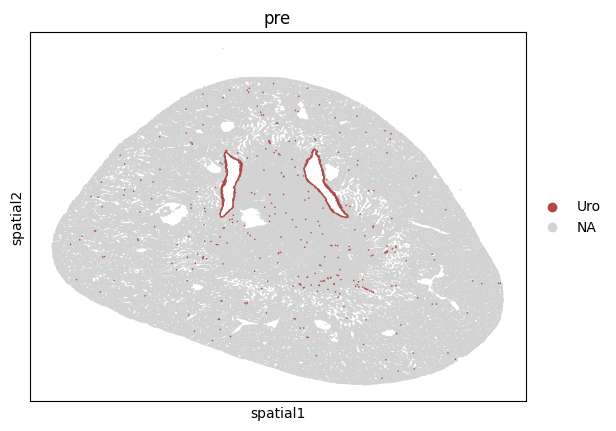

In [12]:
sc.pl.embedding(model.st_ad, basis = 'spatial', color = 'pre', groups = 'Uro',size = 5)

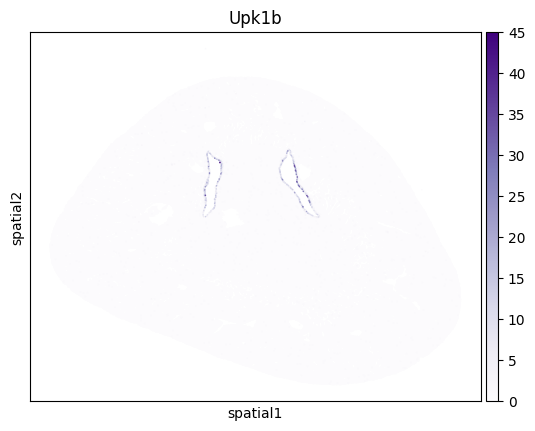

In [13]:
sc.pl.embedding(model.st_ad, basis = 'spatial', color = 'Upk1b', size = 5,cmap='Purples')

In [14]:
model.st_ad.write_h5ad('./results/Day2_Kidney.h5ad')